<a href="https://colab.research.google.com/github/Janahmedtawfik/Janahmedtawfik/blob/main/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
import pandas as pd
import os
df['TotalCharges'].dtype

In [4]:
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
csv = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [6]:
df = pd.read_csv(csv)

In [10]:
df.head(15)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [11]:
churn_rate = df['Churn'].value_counts(normalize=True)*100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [15]:
df['TotalCharges'].dtype #object need to change to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].dtype

dtype('float64')

In [19]:
df = df.drop_duplicates()

In [20]:
df = df.dropna()

**EDA**

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

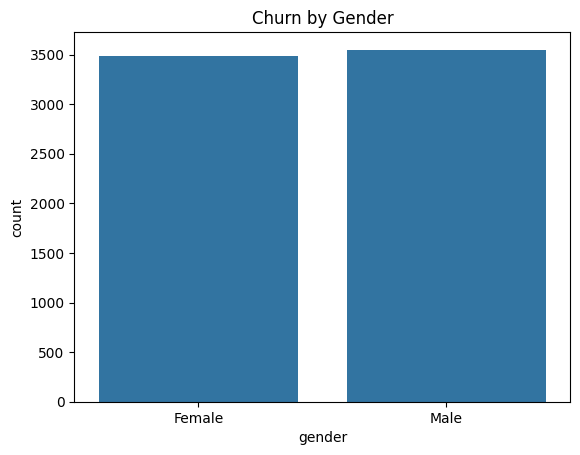

In [22]:
sns.countplot(x='gender', data=df)
plt.title("Churn by Gender")
plt.show() #almost equal

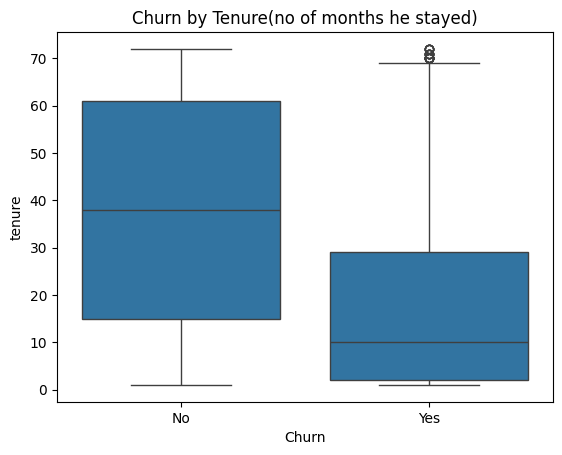

In [24]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Churn by Tenure(no of months he stayed)")
plt.show() # the lower the more churn rate

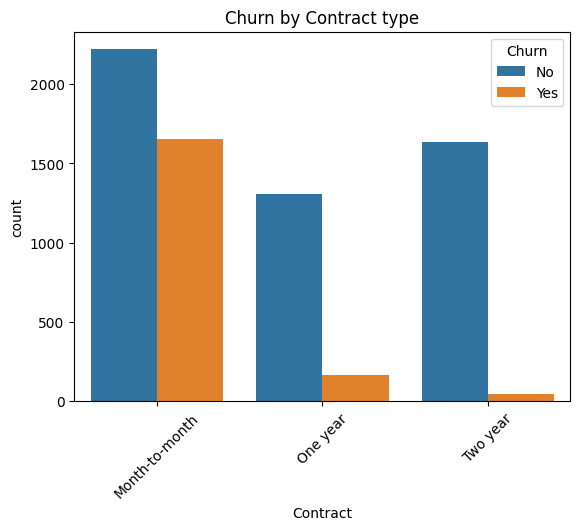

In [25]:
sns.countplot(x='Contract', hue = 'Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Contract type")
plt.show() #highest churn rate month to month

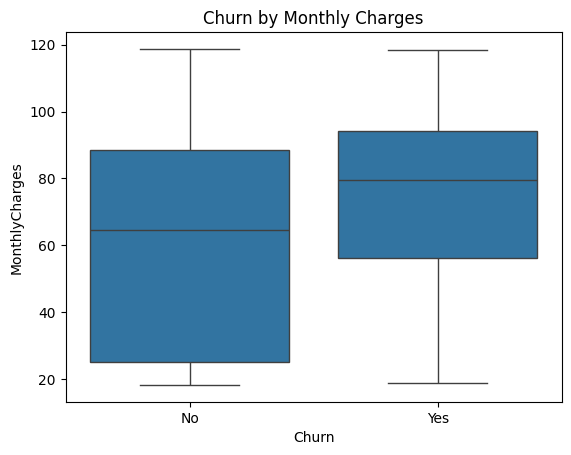

In [26]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Churn by Monthly Charges")
plt.show() #the higher monthly charges the more employees leave

In [27]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [34]:
x = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

In [35]:
x = pd.get_dummies(x, drop_first=True)

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [39]:
y_pred = rf.predict(x_test)

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_prob = rf.predict_proba(x_test)[:,1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

[[927 106]
 [196 178]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

ROC-AUC Score: 0.8160205206785698
